In [1]:
# %%
# =============================================================================
#  Quad9  –  Biquadratic Lagrangian Quadrilateral  (9 nodes · 18 DOF)
#  Complete notebook – follows Quad4 reference structure exactly
# =============================================================================
#
#  Node layout (ξ,η ∈ [-1,1]):
#
#   4 ---7--- 3
#   |         |
#   8    9    6
#   |         |
#   1 ---5--- 2
#
#  Nodes 1-4: corners  |  5-8: mid-sides  |  9: center
#  Integration: Gauss-Legendre n×n over [-1,1]²   (n_gauss ≥ 3)

import numpy as np
from numpy.polynomial.legendre import leggauss

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from ipywidgets import interact, FloatSlider, IntSlider, fixed

np.set_printoptions(precision=4, suppress=True, linewidth=200)

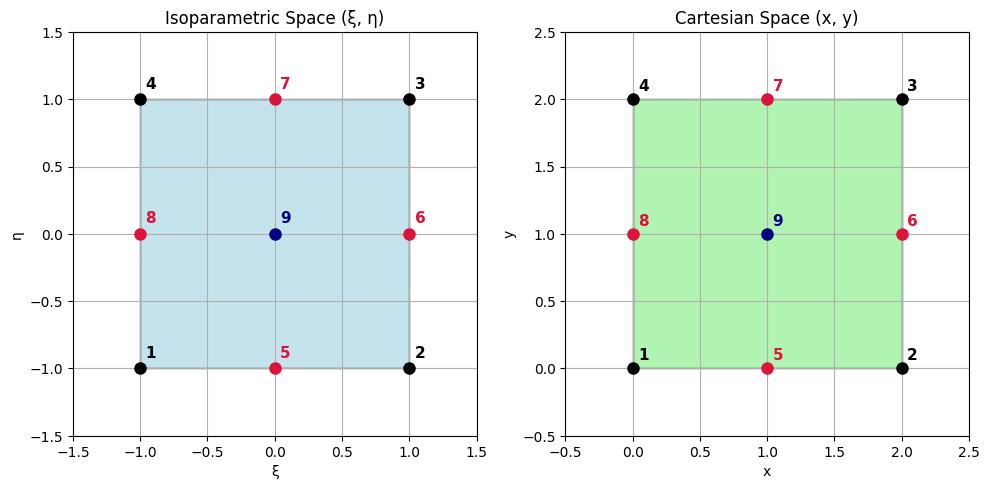

In [2]:
# Define nodal coordinates

nodes_cartesian = np.array([
    [0.0, 0.0],   # Node 1  corner
    [2.0, 0.0],   # Node 2  corner
    [2.0, 2.0],   # Node 3  corner
    [0.0, 2.0],   # Node 4  corner
    [1.0, 0.0],   # Node 5  mid-side 1-2
    [2.0, 1.0],   # Node 6  mid-side 2-3
    [1.0, 2.0],   # Node 7  mid-side 3-4
    [0.0, 1.0],   # Node 8  mid-side 4-1
    [1.0, 1.0],   # Node 9  center
])

# Isoparametric coordinates

nodes_iso = np.array([
    [-1.0,-1.0],  # Node 1
    [ 1.0,-1.0],  # Node 2
    [ 1.0, 1.0],  # Node 3
    [-1.0, 1.0],  # Node 4
    [ 0.0,-1.0],  # Node 5
    [ 1.0, 0.0],  # Node 6
    [ 0.0, 1.0],  # Node 7
    [-1.0, 0.0],  # Node 8
    [ 0.0, 0.0],  # Node 9
])


# Node color scheme: corners black, mid-sides crimson, center navy
colors9 = ['black']*4 + ['crimson']*4 + ['navy']

# Plot Isoparametric space

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax1 = axes[0]
ax1.add_patch(Polygon(nodes_iso[:4], closed=True, edgecolor='black', facecolor='lightblue', alpha=0.7))
for i,(x,y) in enumerate(nodes_iso, 1):
    ax1.plot(x, y, 'o', color=colors9[i-1], markersize=8)
    ax1.text(x+0.04, y+0.06, f'{i}', ha='left', va='bottom',
             fontsize=11, fontweight='bold', color=colors9[i-1])
ax1.set_title('Isoparametric Space (ξ, η)')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_aspect('equal')
ax1.grid(True)
ax1.set_xlabel('ξ')
ax1.set_ylabel('η')

ax2 = axes[1]
ax2.add_patch(Polygon(nodes_cartesian[:4], closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.7))
for i,(x,y) in enumerate(nodes_cartesian, 1):
    ax2.plot(x, y, 'o', color=colors9[i-1], markersize=8)
    ax2.text(x+0.04, y+0.04, f'{i}', ha='left', va='bottom',
             fontsize=11, fontweight='bold', color=colors9[i-1])
ax2.set_title('Cartesian Space (x, y)')
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(-0.5, 2.5)
ax2.set_aspect('equal')
ax2.grid(True)
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

In [3]:
# ----------------------------------
# Shape functions and their derivatives
# ----------------------------------

def shape_functions(xi, eta):
    N1 = 0.25*(xi**2 - xi)*(eta**2 - eta)
    N2 = 0.25*(xi**2 + xi)*(eta**2 - eta)
    N3 = 0.25*(xi**2 + xi)*(eta**2 + eta)
    N4 = 0.25*(xi**2 - xi)*(eta**2 + eta)
    N5 = 0.5 *(1 - xi**2)*(eta**2 - eta)
    N6 = 0.5 *(xi**2 + xi)*(1 - eta**2)
    N7 = 0.5 *(1 - xi**2)*(eta**2 + eta)
    N8 = 0.5 *(xi**2 - xi)*(1 - eta**2)
    N9 = (1 - xi**2)*(1 - eta**2)
    return np.array([[N1],[N2],[N3],[N4],[N5],[N6],[N7],[N8],[N9]])

def shape_function_derivatives(xi, eta):
    dN_dxi = np.array([
        0.25*(2*xi - 1)*(eta**2 - eta),
        0.25*(2*xi + 1)*(eta**2 - eta),
        0.25*(2*xi + 1)*(eta**2 + eta),
        0.25*(2*xi - 1)*(eta**2 + eta),
        0.5 *(-2*xi)   *(eta**2 - eta),
        0.5 *(2*xi + 1)*(1 - eta**2),
        0.5 *(-2*xi)   *(eta**2 + eta),
        0.5 *(2*xi - 1)*(1 - eta**2),
        (-2*xi)*(1 - eta**2)
    ])
    dN_deta = np.array([
        0.25*(xi**2 - xi)*(2*eta - 1),
        0.25*(xi**2 + xi)*(2*eta - 1),
        0.25*(xi**2 + xi)*(2*eta + 1),
        0.25*(xi**2 - xi)*(2*eta + 1),
        0.5 *(1 - xi**2)*(2*eta - 1),
        0.5 *(xi**2 + xi)*(-2*eta),
        0.5 *(1 - xi**2)*(2*eta + 1),
        0.5 *(xi**2 - xi)*(-2*eta),
        (1 - xi**2)*(-2*eta)
    ])
    return dN_dxi, dN_deta


# -------------------------------
# Jacobian matrix and determinant
# -------------------------------

def jacobian_matrix(coords, xi, eta):
    dN_dxi, dN_deta = shape_function_derivatives(xi, eta)
    J = np.zeros((2, 2))
    for i in range(9):
        J[0, 0] += dN_dxi[i]  * coords[i, 0]
        J[0, 1] += dN_dxi[i]  * coords[i, 1]
        J[1, 0] += dN_deta[i] * coords[i, 0]
        J[1, 1] += dN_deta[i] * coords[i, 1]
    return J

def jacobian_determinant(J):
    return np.linalg.det(J)

# ----------------------------------------
# Partial derivatives with respect to x, y
# ----------------------------------------

def shape_function_derivatives_global(coords, xi, eta):
    dN_dxi, dN_deta = shape_function_derivatives(xi, eta)
    J     = jacobian_matrix(coords, xi, eta)
    J_inv = np.linalg.inv(J)
    dN_dx = []
    dN_dy = []
    for i in range(9):
        dN_nat  = np.array([dN_dxi[i], dN_deta[i]])
        dN_phys = J_inv @ dN_nat
        dN_dx.append(dN_phys[0])
        dN_dy.append(dN_phys[1])
    return np.array(dN_dx), np.array(dN_dy)

# ---------------------------
# B matrix (Strain-Displacement)
# ---------------------------

def strain_displacement_matrix(coords, xi, eta):
    dN_dx, dN_dy = shape_function_derivatives_global(coords, xi, eta)
    B = np.zeros((3, 18))
    for i in range(9):
        B[0, 2*i]     = dN_dx[i]
        B[1, 2*i + 1] = dN_dy[i]
        B[2, 2*i]     = dN_dy[i]
        B[2, 2*i + 1] = dN_dx[i]
    return B

def generalized_interpolation(xi, eta, data_matrix):
    N = shape_functions(xi, eta)
    return (data_matrix @ N).flatten()

# -------------------------------
# Utility: Axis limits
# -------------------------------

def get_limits(coords, margin=0.3):
    x_min, y_min = np.min(coords, axis=0)
    x_max, y_max = np.max(coords, axis=0)
    return (x_min - margin, x_max + margin), (y_min - margin, y_max + margin)

def annotate_top_right(ax, value, fmt='.4f'):
    ax.annotate(f'{value:{fmt}}',
                xy=(0.98, 0.98), xycoords='axes fraction',
                fontsize=10, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

def compute_element_area(coords):
    x, y = coords[:, 0], coords[:, 1]
    n = len(x)
    area = 0.0
    for i in range(n):
        area += x[i]*y[(i+1)%n] - x[(i+1)%n]*y[i]
    return 0.5 * abs(area)

def constitutive_matrix(E=210e9, nu=0.3):
    coef = E / (1 - nu**2)
    return coef * np.array([
        [1,     nu,    0],
        [nu,    1,     0],
        [0,     0, (1 - nu) / 2]
    ])


def integrand_trace(coords, xi, eta, E_mat, t=1.0):
    """Compute trace of B^T E B * |J| at a given xi, eta"""
    B = strain_displacement_matrix(coords, xi, eta)
    J = jacobian_matrix(coords, xi, eta)
    detJ = jacobian_determinant(J)
    K_local = B.T @ E_mat @ B
    return t * detJ * np.trace(K_local)

def compute_integrand_matrix(coords, xi, eta, E_mat, t=1.0):
    B = strain_displacement_matrix(coords, xi, eta)
    J = jacobian_matrix(coords, xi, eta)
    detJ = jacobian_determinant(J)

    return t * detJ * (B.T @ E_mat @ B)

def simpson_2d(f_grid, h_xi, h_eta):
    """
    Applies the composite 2D Simpson's rule to a grid f_grid.
    Assumes an odd number of points (e.g., 51 x 51).
    """
    if f_grid.shape[0] % 2 == 0 or f_grid.shape[1] % 2 == 0:
        raise ValueError("Simpson's rule requires an odd number of points in each dimension.")

    m, n = f_grid.shape
    S = 0

    for i in range(m):
        for j in range(n):
            coef_i = 2 + 2*(i % 2)
            coef_j = 2 + 2*(j % 2)
            if i == 0 or i == m-1:
                coef_i = 1
            if j == 0 or j == n-1:
                coef_j = 1
            S += coef_i * coef_j * f_grid[i, j]

    return (h_xi * h_eta / 9) * S

def gauss_points(n):
    """
    Returns Gauss-Legendre quadrature points and weights for [-1, 1].
    """
    pts_1d, w_1d = leggauss(n)
    Xi, Eta = np.meshgrid(pts_1d, pts_1d)
    Wxi, Weta = np.meshgrid(w_1d, w_1d)
    points  = np.column_stack((Xi.flatten(), Eta.flatten()))
    weights = (Wxi * Weta).flatten()
    return points, weights

def gauss_integrate_component(func, idx, coords, E_mat, n_gauss):
    """
    Integrates K_{ii}(xi, eta) over the domain using 2D Gauss-Legendre quadrature.

    - func: function compute_integrand_matrix
    - idx: component index K_{ii}
    - coords: element coordinates
    - E_mat: constitutive matrix
    - n_gauss: quadrature order (e.g., 2 → 2x2 points)

    Returns:
    - integral (float)
    """
    pts_1d, w_1d = leggauss(n_gauss)
    xi_pts = 0.5*(pts_1d + 1.0)
    xi_wts = 0.5*w_1d
    integral = 0.0
    for xi, wi in zip(xi_pts, xi_wts):
        for eta_h, wj in zip(xi_pts, xi_wts):
            eta    = eta_h * (1.0 - xi)
            weight = wi * wj * (1.0 - xi)
            integral += weight * func(coords, xi, eta, E_mat)[idx, idx]
    return integral

# -------------------------------
#  STIFFNESS MATRIX 
# -------------------------------

def compute_stiffness_matrix(coords, E=210e9, nu=0.3, t=1.0, n_gauss=3):
    E_mat  = constitutive_matrix(E, nu)
    points, weights = gauss_points(n_gauss)
    K = np.zeros((18, 18))
    for (xi, eta), w in zip(points, weights):
        B    = strain_displacement_matrix(coords, xi, eta)
        J    = jacobian_matrix(coords, xi, eta)
        detJ = jacobian_determinant(J)
        K   += B.T @ E_mat @ B * detJ * t * w
    return K

def check_symmetry(K):
    """
    Checks the symmetry of the stiffness matrix.

    Returns the maximum absolute error between K and its transpose.
    """
    return np.max(np.abs(K - K.T))

def rigid_body_modes():
    """
    Returns displacement vectors for rigid body modes:
    - Translation in x
    - Translation in y
    - Rotation around the centroid
    """
    ux  = np.array([1, 0] * 9, dtype=float)
    uy  = np.array([0, 1] * 9, dtype=float)
    
    # Nodal positions (x, y)
    cx, cy = nodes_cartesian.mean(axis=0)
    rot = []
    for x, y in nodes_cartesian:
        rot += [-(y - cy), (x - cx)]
    rot = np.array(rot)

    return ux, uy, rot

def internal_energy(K, u):
    """
    Computes the internal energy U = 0.5 * uᵀ K u
    """
    return 0.5 * u.T @ K @ u

def verify_rigid_body_modes(K, verbose=True):
    """
    Evaluates internal energy for the 3 rigid body modes and displays results.
    """
    ux, uy, rot = rigid_body_modes()
    
    e_x = internal_energy(K, ux)
    e_y = internal_energy(K, uy)
    e_r = internal_energy(K, rot)
    sym_err = check_symmetry(K)

    if verbose:
        print(f"  Symmetry error      : {sym_err:.6e}  (should be ~0)")
        print(f"  Energy ux  (RBM)    : {e_x:.6e}")
        print(f"  Energy uy  (RBM)    : {e_y:.6e}")
        print(f"  Energy rot (RBM)    : {e_r:.6e}")
    return sym_err, e_x, e_y, e_r


In [4]:
# --- Plotting function ---
def plot_mapping(xi, eta):
    clear_output(wait=True)

    data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim,  iso_ylim  = (-1.4, 1.4), (-1.4, 1.4)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian[:4], 0.5)

    fig = plt.figure(figsize=(28, 14), dpi=100, constrained_layout=True)
    gs  = fig.add_gridspec(3, 5, height_ratios=[1.1, 1, 1])

    ax1    = fig.add_subplot(gs[0, 0])
    ax2    = fig.add_subplot(gs[0, 1])
    axB    = fig.add_subplot(gs[0, 2:5])
    axs_sf = [fig.add_subplot(gs[1 + k//5, k%5]) for k in range(9)]

    # --- Isoparametric view ---
    ax1.add_patch(Polygon(nodes_iso[:4], closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i,(x,y) in enumerate(nodes_iso, 1):
        ax1.plot(x,y,'o',color=colors9[i-1],markersize=8)
        ax1.text(x+0.06,y+0.06,str(i),fontsize=10,fontweight='bold',color=colors9[i-1])
    ax1.plot(xi, eta, 'rs', markersize=10)
    ax1.set_title('Isoparametric Space $(\\xi, \\eta)$', fontsize=12)
    ax1.set_xlim(*iso_xlim); ax1.set_ylim(*iso_ylim)
    ax1.set_aspect('equal'); ax1.grid(True)
    ax1.set_xlabel('ξ'); ax1.set_ylabel('η')

    # --- Cartesian view ---
    ax2.add_patch(Polygon(nodes_cartesian[:4], closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i,(x,y) in enumerate(nodes_cartesian, 1):
        ax2.plot(x,y,'o',color=colors9[i-1],markersize=8)
        ax2.text(x+0.04,y+0.04,str(i),fontsize=10,fontweight='bold',color=colors9[i-1])
    ax2.plot(x_mapped, y_mapped, 'rs', markersize=10)
    ax2.set_title('Cartesian Space $(x, y)$', fontsize=12)
    ax2.set_xlim(*cart_xlim); ax2.set_ylim(*cart_ylim)
    ax2.set_aspect('equal'); ax2.grid(True)
    ax2.set_xlabel('x'); ax2.set_ylabel('y')

    # B matrix table
    B = strain_displacement_matrix(nodes_cartesian, xi, eta)
    axB.axis('off')
    col_labels = [f'$u_{i+1}$' for i in range(18)]
    row_labels  = [r'$\varepsilon_x$', r'$\varepsilon_y$', r'$\gamma_{xy}$']
    tbl = axB.table(
        cellText=[[f'{B[r,c]:.1e}' for c in range(18)] for r in range(3)],
        rowLabels=row_labels, colLabels=col_labels,
        loc='center', cellLoc='center', edges='closed')
    tbl.scale(1.0, 1.8); tbl.set_fontsize(7)
    axB.set_title('Strain-Displacement Matrix $[B]$', fontsize=14, pad=10)

    # --- Shape function plots ---
    res = 40
    xi_g  = np.linspace(-1, 1, res); eta_g = np.linspace(-1, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    N_pt = shape_functions(xi, eta).flatten()

    sf_names = [
        r'$N_1=\frac{1}{4}(\xi^2-\xi)(\eta^2-\eta)$',
        r'$N_2=\frac{1}{4}(\xi^2+\xi)(\eta^2-\eta)$',
        r'$N_3=\frac{1}{4}(\xi^2+\xi)(\eta^2+\eta)$',
        r'$N_4=\frac{1}{4}(\xi^2-\xi)(\eta^2+\eta)$',
        r'$N_5=\frac{1}{2}(1-\xi^2)(\eta^2-\eta)$',
        r'$N_6=\frac{1}{2}(\xi^2+\xi)(1-\eta^2)$',
        r'$N_7=\frac{1}{2}(1-\xi^2)(\eta^2+\eta)$',
        r'$N_8=\frac{1}{2}(\xi^2-\xi)(1-\eta^2)$',
        r'$N_9=(1-\xi^2)(1-\eta^2)$'
    ]

    for k, ax in enumerate(axs_sf):
        Ni_grid = np.zeros((res, res))
        for i in range(res):
            for j in range(res):
                Ni_grid[i,j] = shape_functions(Xi[i,j], Eta[i,j]).flatten()[k]

        cf = ax.contourf(Xi, Eta, Ni_grid, levels=20, cmap='viridis')
        ax.plot(xi, eta, 'rs', markersize=5)
        ax.set_title(sf_names[k], fontsize=8)
        ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
        ax.set_aspect('equal'); ax.grid(True)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        annotate_top_right(ax, N_pt[k])
        fig.colorbar(cf, ax=ax)

    plt.show()

# --- Widget setup ---
interact(plot_mapping,
         xi =FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_mapping(xi, eta)>

In [5]:
# Plotting
def plot_mapping_3d(xi, eta):
    clear_output(wait=True)

    data_matrix = np.vstack([nodes_cartesian[:,0], nodes_cartesian[:,1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim, iso_ylim   = (-1.4,1.4),(-1.4,1.4)
    cart_xlim,cart_ylim  = get_limits(nodes_cartesian[:4], 0.5)

    fig = plt.figure(figsize=(28, 18), dpi=100, constrained_layout=True)
    gs  = fig.add_gridspec(2, 9, height_ratios=[1.1, 1])
    # gs  = fig.add_gridspec(4, 3, height_ratios=[1.1, 1, 1, 1])

    ax1    = fig.add_subplot(gs[0, 0])
    ax2    = fig.add_subplot(gs[0, 1])
    axs_3d = [fig.add_subplot(gs[1, i], projection='3d') for i in range(9)]
    # axs_3d = [fig.add_subplot(gs[1 + k//3, k%3], projection='3d') for k in range(9)]

    # Isoparametric view
    ax1.add_patch(Polygon(nodes_iso[:4], closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i,(x,y) in enumerate(nodes_iso,1):
        ax1.plot(x,y,'o',color=colors9[i-1],markersize=7)
        ax1.text(x+0.06,y+0.06,str(i),fontsize=9,fontweight='bold',color=colors9[i-1])
    ax1.plot(xi,eta,'rs',markersize=10)
    ax1.set_title('Isoparametric Space $(\\xi,\\eta)$',fontsize=12)
    ax1.set_xlim(*iso_xlim); ax1.set_ylim(*iso_ylim); ax1.set_aspect('equal'); ax1.grid(True)

    # Cartesian view
    ax2.add_patch(Polygon(nodes_cartesian[:4], closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i,(x,y) in enumerate(nodes_cartesian,1):
        ax2.plot(x,y,'o',color=colors9[i-1],markersize=7)
        ax2.text(x+0.04,y+0.04,str(i),fontsize=9,fontweight='bold',color=colors9[i-1])
    ax2.plot(x_mapped,y_mapped,'rs',markersize=10)
    ax2.set_title('Cartesian Space $(x,y)$',fontsize=12)
    ax2.set_xlim(*cart_xlim); ax2.set_ylim(*cart_ylim); ax2.set_aspect('equal'); ax2.grid(True)

    # 3D surfaces
    res = 50
    xi_g  = np.linspace(-1,1,res); eta_g = np.linspace(-1,1,res)
    Xi,Eta = np.meshgrid(xi_g,eta_g)
    N_pt = shape_functions(xi,eta).flatten()

    for k,ax in enumerate(axs_3d):
        Ni_grid = np.zeros((res,res))
        for i in range(res):
            for j in range(res):
                Ni_grid[i,j] = shape_functions(Xi[i,j],Eta[i,j]).flatten()[k]

        ax.plot_surface(Xi,Eta,Ni_grid,cmap='viridis',edgecolor='k',linewidth=0.2,alpha=0.9)
        ax.scatter(xi,eta,N_pt[k],color='r',s=30)
        ax.set_title(f'$N_{k+1}(\\xi,\\eta)$',fontsize=9)
        ax.set_xlabel('ξ'); ax.set_ylabel('η'); ax.set_zlabel(f'$N_{k+1}$')
        ax.view_init(elev=30,azim=-45)
        ax.set_xlim(-1,1); ax.set_ylim(-1,1)

    fig.suptitle('Quad9 Shape Functions as 3D Surfaces',fontsize=15,fontweight='bold')
    plt.show()

interact(plot_mapping_3d,
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_mapping_3d(xi, eta)>

In [6]:
shape_functions(1.0, 0.0)

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.]])

In [7]:
data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
x_mapped, y_mapped = generalized_interpolation(0.5, 0.5, data_matrix)

In [8]:
# --- Main visualization function ---
def plot_mapping_full(xi, eta):
    clear_output(wait=True)

    data_matrix = np.vstack([nodes_cartesian[:,0], nodes_cartesian[:,1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim, iso_ylim  = (-1.4,1.4),(-1.4,1.4)
    cart_xlim,cart_ylim = get_limits(nodes_cartesian[:4], 0.5)

    fig = plt.figure(figsize=(28, 26), dpi=100, constrained_layout=True)
    # rows: header + 3 rows of 3 for each derivative type
    gs  = fig.add_gridspec(4, 9, height_ratios=[1.2, 1, 1, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    axB = fig.add_subplot(gs[0, 2:9])
    # 3 rows × 3 cols per derivative type → 9 subplots each
    axs_sf   = [fig.add_subplot(gs[1, i]) for i in range(9)]
    axs_dxi  = [fig.add_subplot(gs[2, i]) for i in range(9)]
    axs_deta = [fig.add_subplot(gs[3, i]) for i in range(9)]

    # Isoparametric view
    ax1.add_patch(Polygon(nodes_iso[:4], closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i,(x,y) in enumerate(nodes_iso,1):
        ax1.plot(x,y,'o',color=colors9[i-1],markersize=6)
        ax1.text(x+0.06,y+0.06,str(i),fontsize=9,fontweight='bold',color=colors9[i-1])
    ax1.plot(xi,eta,'rs',markersize=10)
    ax1.set_title('Isoparametric $(\\xi,\\eta)$',fontsize=12)
    ax1.set_xlim(*iso_xlim); ax1.set_ylim(*iso_ylim); ax1.set_aspect('equal'); ax1.grid(True)

    # Cartesian view
    ax2.add_patch(Polygon(nodes_cartesian[:4], closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i,(x,y) in enumerate(nodes_cartesian,1):
        ax2.plot(x,y,'o',color=colors9[i-1],markersize=6)
        ax2.text(x+0.04,y+0.04,str(i),fontsize=9,fontweight='bold',color=colors9[i-1])
    ax2.plot(x_mapped,y_mapped,'rs',markersize=10)
    ax2.set_title('Cartesian $(x,y)$',fontsize=12)
    ax2.set_xlim(*cart_xlim); ax2.set_ylim(*cart_ylim); ax2.set_aspect('equal'); ax2.grid(True)

    # B matrix table
    B = strain_displacement_matrix(nodes_cartesian, xi, eta)
    axB.axis('off')
    tbl = axB.table(
        cellText=[[f'{B[r,c]:.1e}' for c in range(18)] for r in range(3)],
        rowLabels=[r'$\varepsilon_x$',r'$\varepsilon_y$',r'$\gamma_{xy}$'],
        colLabels=[f'$u_{i+1}$' for i in range(18)],
        loc='center', cellLoc='center', edges='closed')
    tbl.scale(1.0,1.8); tbl.set_fontsize(7)
    axB.set_title('Strain-Displacement Matrix $[B]$', fontsize=14, pad=10)

    # Grid
    res = 35
    xi_g  = np.linspace(-1,1,res); eta_g = np.linspace(-1,1,res)
    Xi,Eta = np.meshgrid(xi_g,eta_g)
    N_pt = shape_functions(xi,eta).flatten()
    d1_pt,d2_pt = shape_function_derivatives(xi,eta)

    for k in range(9):
        Ni_g   = np.zeros((res,res))
        dxi_g  = np.zeros((res,res))
        deta_g = np.zeros((res,res))
        for i in range(res):
            for j in range(res):
                Ni_g[i,j]   = shape_functions(Xi[i,j],Eta[i,j]).flatten()[k]
                d1,d2       = shape_function_derivatives(Xi[i,j],Eta[i,j])
                dxi_g[i,j]  = d1[k]
                deta_g[i,j] = d2[k]

        for ax, Z, val, title, cmap in [
            (axs_sf[k],   Ni_g,   N_pt[k],  f'$N_{k+1}$',                          'viridis'),
            (axs_dxi[k],  dxi_g,  d1_pt[k], f'$\\partial N_{k+1}/\\partial\\xi$',  'coolwarm'),
            (axs_deta[k], deta_g, d2_pt[k], f'$\\partial N_{k+1}/\\partial\\eta$', 'cividis'),
        ]:
            cf = ax.contourf(Xi,Eta,Z,levels=20,cmap=cmap)
            ax.plot(xi,eta,'rs',markersize=4)
            ax.set_title(title,fontsize=9)
            ax.set_xlim(-1.05,1.05); ax.set_ylim(-1.05,1.05)
            ax.set_aspect('equal'); ax.grid(True)
            ax.set_xlabel('ξ'); ax.set_ylabel('η')
            annotate_top_right(ax, val)
            fig.colorbar(cf,ax=ax)

    plt.show()

interact(plot_mapping_full,
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_mapping_full(xi, eta)>

In [9]:
area = compute_element_area(nodes_cartesian)

def plot_jacobian_fields(xi, eta):
    clear_output(wait=True)

    res = 40
    xi_g  = np.linspace(-1,1,res); eta_g = np.linspace(-1,1,res)
    Xi,Eta = np.meshgrid(xi_g,eta_g)

    J11=np.zeros((res,res)); J12=np.zeros((res,res))
    J21=np.zeros((res,res)); J22=np.zeros((res,res))
    detJ_grid=np.zeros((res,res))

    for i in range(res):
        for j in range(res):
            J = jacobian_matrix(nodes_cartesian, Xi[i,j], Eta[i,j])
            J11[i,j]=J[0,0]; J12[i,j]=J[0,1]
            J21[i,j]=J[1,0]; J22[i,j]=J[1,1]
            detJ_grid[i,j]=np.linalg.det(J)

    data_matrix = np.vstack([nodes_cartesian[:,0], nodes_cartesian[:,1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim, iso_ylim  = (-1.4,1.4),(-1.4,1.4)
    cart_xlim,cart_ylim = get_limits(nodes_cartesian[:4], 0.5)
    J_at_pt    = jacobian_matrix(nodes_cartesian, xi, eta)
    detJ_at_pt = jacobian_determinant(J_at_pt)

    fig, axs = plt.subplots(3, 3, figsize=(18, 14), dpi=100, constrained_layout=True)

    axs[0,0].add_patch(Polygon(nodes_iso[:4], closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i,(x,y) in enumerate(nodes_iso,1):
        axs[0,0].plot(x,y,'o',color=colors9[i-1],markersize=6)
        axs[0,0].text(x+0.06,y+0.06,str(i),fontsize=8,fontweight='bold',color=colors9[i-1])
    axs[0,0].plot(xi,eta,'rs',markersize=8)
    axs[0,0].set_title('Isoparametric Space $(\\xi,\\eta)$')
    axs[0,0].set_xlim(*iso_xlim); axs[0,0].set_ylim(*iso_ylim)
    axs[0,0].set_aspect('equal'); axs[0,0].grid(True)

    axs[0,1].add_patch(Polygon(nodes_cartesian[:4], closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i,(x,y) in enumerate(nodes_cartesian,1):
        axs[0,1].plot(x,y,'o',color=colors9[i-1],markersize=6)
        axs[0,1].text(x+0.04,y+0.04,str(i),fontsize=8,fontweight='bold',color=colors9[i-1])
    axs[0,1].plot(x_mapped,y_mapped,'rs',markersize=8)
    axs[0,1].set_title('Physical Space $(x,y)$')
    axs[0,1].set_xlim(*cart_xlim); axs[0,1].set_ylim(*cart_ylim)
    axs[0,1].set_aspect('equal'); axs[0,1].grid(True)

    fields = [
        (detJ_grid,      r'Determinant $|J|$',          'viridis',  detJ_at_pt,       '.2e', (0,2)),
        (J11,            r'$\partial x/\partial\xi$',   'coolwarm', J_at_pt[0,0],     '.2e', (1,0)),
        (J12,            r'$\partial y/\partial\xi$',   'coolwarm', J_at_pt[0,1],     '.2e', (1,1)),
        (detJ_grid/area, r'Determinant $|J|$ / Area',  'viridis',  detJ_at_pt/area,  '.3f', (1,2)),
        (J21,            r'$\partial x/\partial\eta$',  'cividis',  J_at_pt[1,0],     '.2e', (2,0)),
        (J22,            r'$\partial y/\partial\eta$',  'cividis',  J_at_pt[1,1],     '.2e', (2,1)),
    ]
    for Z, title, cmap, val, fmt, (r, c) in fields:
        cf = axs[r,c].contourf(Xi,Eta,Z,levels=20,cmap=cmap)
        axs[r,c].plot(xi,eta,'rs',markersize=5)
        axs[r,c].set_title(title); axs[r,c].set_aspect('equal')
        fig.colorbar(cf, ax=axs[r,c])
        annotate_top_right(axs[r,c], val, fmt=fmt)

    axs[2,2].axis('off')
    plt.show()

interact(plot_jacobian_fields,
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_jacobian_fields(xi, eta)>

In [10]:
# Material properties
E=210e9  # Young's modulus in Pa
nu=0.3  # Poisson's ratio
t=0.01  # Thickness in m

Emat = constitutive_matrix(E=E, nu=nu)

In [11]:
def plot_stiffness_integrand(E_mat, xi_eval=0.0, eta_eval=0.0):
    clear_output(wait=True)

    res = 40
    xi_g  = np.linspace(-1,1,res); eta_g = np.linspace(-1,1,res)
    Xi,Eta = np.meshgrid(xi_g,eta_g)
    Z = np.zeros((res,res))
    for i in range(res):
        for j in range(res):
            Z[i,j] = integrand_trace(nodes_cartesian, Xi[i,j], Eta[i,j], E_mat, t)

    Z_point = integrand_trace(nodes_cartesian, xi_eval, eta_eval, E_mat, t)

    fig = plt.figure(figsize=(16, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    c = ax1.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
    ax1.plot(xi_eval, eta_eval, 'ro')
    annotate_top_right(ax1, Z_point, fmt='.2e')
    ax1.set_title(r'Trace of Integrand $B^T E B \, |J|$')
    ax1.set_xlabel('ξ'); ax1.set_ylabel('η')
    fig.colorbar(c, ax=ax1); ax1.grid(True); ax1.set_aspect('equal')

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', alpha=0.95, linewidth=0.1)
    ax2.scatter(xi_eval, eta_eval, Z_point, color='r', s=30)
    ax2.set_title('Integrand in 3D')
    ax2.set_xlabel('ξ'); ax2.set_ylabel('η'); ax2.set_zlabel('Scalar Value')
    ax2.view_init(elev=30, azim=-45)
    plt.tight_layout(); plt.show()

interact(lambda xi, eta: plot_stiffness_integrand(Emat, xi, eta),
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.<lambda>(xi, eta)>

In [12]:
def plot_stiffness_diagonal_interactive(E_mat, xi=0.0, eta=0.0):
    clear_output(wait=True)

    res = 35
    xi_g  = np.linspace(-1,1,res); eta_g = np.linspace(-1,1,res)
    Xi,Eta = np.meshgrid(xi_g,eta_g)

    fig, axs = plt.subplots(3, 6, figsize=(28, 12), constrained_layout=True)
    axs = axs.flatten()

    for idx in range(18):
        Z = np.zeros((res,res))
        for r in range(res):
            for c in range(res):
                K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r,c], Eta[r,c], E_mat, t)
                Z[r,c] = K_loc[idx, idx]

        Z_point = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat, t)[idx, idx]
        ax = axs[idx]
        contour = ax.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
        ax.plot(xi, eta, 'ro')
        annotate_top_right(ax, Z_point, fmt='.2e')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=10)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.set_aspect('equal'); ax.grid(True)
        fig.colorbar(contour, ax=ax)

    fig.suptitle(r'Diagonal Components of Integrand $B^T E B \cdot |J|$',
                 fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_interactive,
         E_mat=fixed(Emat),
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_stiffness_diagonal_interactive(E_mat, xi=0.0, eta=0.0)>

In [13]:
def plot_stiffness_diagonal_interactive_3D(E_mat, xi=0.0, eta=0.0):
    clear_output(wait=True)

    res = 51
    xi_g  = np.linspace(-1,1,res); eta_g = np.linspace(-1,1,res)
    Xi,Eta = np.meshgrid(xi_g,eta_g)
    h = 2.0/(res-1)

    fig = plt.figure(figsize=(32, 14), constrained_layout=True)
    axs = [fig.add_subplot(3, 6, i+1, projection='3d') for i in range(18)]

    for idx, ax in enumerate(axs):
        Z = np.zeros((res,res))
        for r in range(res):
            for c in range(res):
                K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r,c], Eta[r,c], E_mat, t)
                Z[r,c] = K_loc[idx,idx]

        K_pt   = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat, t)[idx, idx]
        volume = simpson_2d(Z, h, h)

        ax.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', linewidth=0.1, alpha=0.95)
        ax.scatter(xi, eta, K_pt, color='r', s=30)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.set_zlabel(rf'$K_{{{idx+1},{idx+1}}}$')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}$', fontsize=9)
        ax.view_init(elev=30, azim=-45)
        ax.text2D(0.5, -0.15, f'Vol = {volume:.2e}', transform=ax.transAxes,
                  ha='center', fontsize=8, bbox=dict(boxstyle='round', fc='wheat', alpha=0.3))

    fig.suptitle(r'Diagonal Components (3D) of Integrand $B^T E B \cdot |J|$',
                 fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_interactive_3D,
         E_mat=fixed(Emat),
         xi =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_stiffness_diagonal_interactive_3D(E_mat, xi=0.0, eta=0.0)>

In [14]:
def plot_stiffness_diagonal_gauss(E_mat, xi=0.0, eta=0.0, n_gauss=3):
    clear_output(wait=True)

    res = 35
    xi_g  = np.linspace(-1,1,res); eta_g = np.linspace(-1,1,res)
    Xi,Eta = np.meshgrid(xi_g,eta_g)

    gauss_pts_list, gauss_wts_list = gauss_points(n_gauss)

    fig, axs = plt.subplots(3, 6, figsize=(30, 12), constrained_layout=True)
    axs = axs.flatten()

    for idx in range(18):
        Z = np.zeros((res,res))
        for r in range(res):
            for c in range(res):
                K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r,c], Eta[r,c], E_mat, t)
                Z[r,c] = K_loc[idx,idx]

        Z_point = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat, t)[idx, idx]
        ax = axs[idx]
        contour = ax.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
        ax.plot(xi, eta, 'ro', label='Current point')

        for (xi_i, eta_i), wi in zip(gauss_pts_list, gauss_wts_list):
            ax.plot(xi_i, eta_i, 'ko', markersize=5, zorder=5)
            ax.text(xi_i, eta_i+0.08, f'({xi_i:.2f},{eta_i:.2f})', fontsize=6,
                    ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85), zorder=6)
            ax.text(xi_i, eta_i-0.08, f'$w$={wi:.3f}', fontsize=6,
                    ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85), zorder=6)

        annotate_top_right(ax, Z_point, fmt='.2e')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi,\eta)$', fontsize=10)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.set_aspect('equal'); ax.grid(True)
        fig.colorbar(contour, ax=ax)

    fig.suptitle(r'Diagonal Components $B^T E B \cdot |J|$ with Gauss Points and Weights',
                 fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_gauss,
         E_mat  =fixed(Emat),
         xi     =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta    =FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0, description='η'),
         n_gauss=IntSlider(min=1, max=5, step=1, value=3, description='Gauss'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, step=0.05), FloatSlider(value=0.0, desc…

<function __main__.plot_stiffness_diagonal_gauss(E_mat, xi=0.0, eta=0.0, n_gauss=3)>

In [15]:
def plot_stiffness_diagonal_3D_gauss(E_mat, xi=0.0, eta=0.0, n_gauss=3):
    clear_output(wait=True)

    res = 51
    xi_g  = np.linspace(-1,1,res); eta_g = np.linspace(-1,1,res)
    Xi,Eta = np.meshgrid(xi_g,eta_g)
    h = 2.0/(res-1)

    fig = plt.figure(figsize=(32, 14), constrained_layout=True)
    axs = [fig.add_subplot(3, 6, i+1, projection='3d') for i in range(18)]

    for idx, ax in enumerate(axs):
        Z = np.zeros((res,res))
        for r in range(res):
            for c in range(res):
                K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r,c], Eta[r,c], E_mat, t)
                Z[r,c] = K_loc[idx,idx]

        K_pt   = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat, t)[idx, idx]
        volume = gauss_integrate_component(compute_integrand_matrix, idx, nodes_cartesian, E_mat, n_gauss)

        ax.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', linewidth=0.1, alpha=0.95)
        ax.scatter(xi, eta, K_pt, color='r', s=30)
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.set_zlabel(rf'$K_{{{idx+1},{idx+1}}}$')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}$', fontsize=9)
        ax.view_init(elev=30, azim=-45)
        ax.text2D(0.5, -0.15, f'Gauss ({n_gauss}×{n_gauss}) Vol = {volume:.2e}',
                  transform=ax.transAxes, ha='center', fontsize=8,
                  bbox=dict(boxstyle='round', fc='wheat', alpha=0.3))

    fig.suptitle('Diagonal Components (3D) with Gauss Quadrature',
                 fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_3D_gauss,
         E_mat  =fixed(Emat),
         xi     =FloatSlider(min=0.0, max=0.95, step=0.05, value=0.0, description='ξ'),
         eta    =FloatSlider(min=0.0, max=0.95, step=0.05, value=0.0, description='η'),
         n_gauss=IntSlider(min=1, max=5, step=1, value=3, description='Gauss'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=0.95, step=0.05), FloatSlider(value=0.0, des…

<function __main__.plot_stiffness_diagonal_3D_gauss(E_mat, xi=0.0, eta=0.0, n_gauss=3)>

In [16]:
np.set_printoptions(precision=3, suppress=True, linewidth=200)

K = compute_stiffness_matrix(nodes_cartesian, E=E, nu=nu, t=t, n_gauss=3)
verify_rigid_body_modes(K)
print("Stiffness Matrix [K]:")
print(K)

  Symmetry error      : 9.536743e-07  (should be ~0)
  Energy ux  (RBM)    : -3.278255e-07
  Energy uy  (RBM)    : -5.960464e-07
  Energy rot (RBM)    : 2.086163e-07
Stiffness Matrix [K]:
[[ 9.692e+08  3.750e+08  3.974e+07  9.615e+06 -3.462e+07 -4.167e+07 -1.436e+08 -9.615e+06 -6.949e+08 -3.846e+07  1.231e+08  1.667e+08  2.231e+08  1.667e+08  7.179e+07  3.846e+07 -5.538e+08
  -6.667e+08]
 [ 3.750e+08  9.692e+08 -9.615e+06 -1.436e+08 -4.167e+07 -3.462e+07  9.615e+06  3.974e+07  3.846e+07  7.179e+07  1.667e+08  2.231e+08  1.667e+08  1.231e+08 -3.846e+07 -6.949e+08 -6.667e+08
  -5.538e+08]
 [ 3.974e+07 -9.615e+06  9.692e+08 -3.750e+08 -1.436e+08  9.615e+06 -3.462e+07  4.167e+07 -6.949e+08  3.846e+07  7.179e+07 -3.846e+07  2.231e+08 -1.667e+08  1.231e+08 -1.667e+08 -5.538e+08
   6.667e+08]
 [ 9.615e+06 -1.436e+08 -3.750e+08  9.692e+08 -9.615e+06  3.974e+07  4.167e+07 -3.462e+07 -3.846e+07  7.179e+07  3.846e+07 -6.949e+08 -1.667e+08  1.231e+08 -1.667e+08  2.231e+08  6.667e+08
  -5.538e+08]
